In [2]:
import pandas as pd
df=pd.read_csv(r"C:\Users\HP\Downloads\bank_customers.csv")
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
total_churned =df['churn'].sum()
churn_rate = round(df['churn'].sum()/len(df)*100,2)
print("Total Churned Customers:",total_churned)
print("Churn Rate (%):",churn_rate)

Total Churned Customers: 204
Churn Rate (%): 20.4


In [4]:
# Example: Gender wise
gender_churn = df.groupby('gender').agg(
    total_customers=('customer_id','count'),
    churned=('churn','sum')
)
gender_churn['churn_rate'] = round(gender_churn['churned']/gender_churn['total_customers']*100,2)
print(gender_churn)

# Example: Country wise
country_churn = df.groupby('country').agg(
    total_customers=('customer_id','count'),
    churned=('churn','sum')
)
country_churn['churn_rate'] = round(country_churn['churned']/country_churn['total_customers']*100,2)
print(country_churn)

        total_customers  churned  churn_rate
gender                                      
Female              467      121       25.91
Male                533       83       15.57
         total_customers  churned  churn_rate
country                                      
France               482       77       15.98
Germany              259       75       28.96
Spain                259       52       20.08


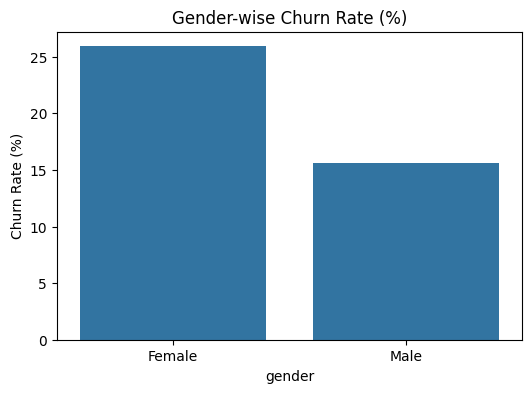

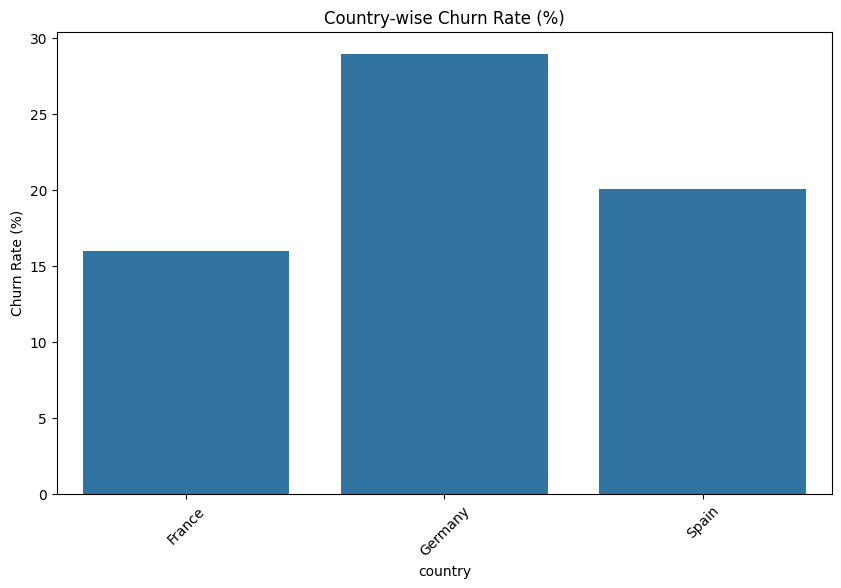

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gender wise churn rate
plt.figure(figsize=(6,4))
sns.barplot(x=gender_churn.index, y=gender_churn['churn_rate'])
plt.title("Gender-wise Churn Rate (%)")
plt.ylabel("Churn Rate (%)")
plt.show()

# Country wise churn rate
plt.figure(figsize=(10,6))
sns.barplot(x=country_churn.index, y=country_churn['churn_rate'])
plt.xticks(rotation=45)
plt.title("Country-wise Churn Rate (%)")
plt.ylabel("Churn Rate (%)")
plt.show()

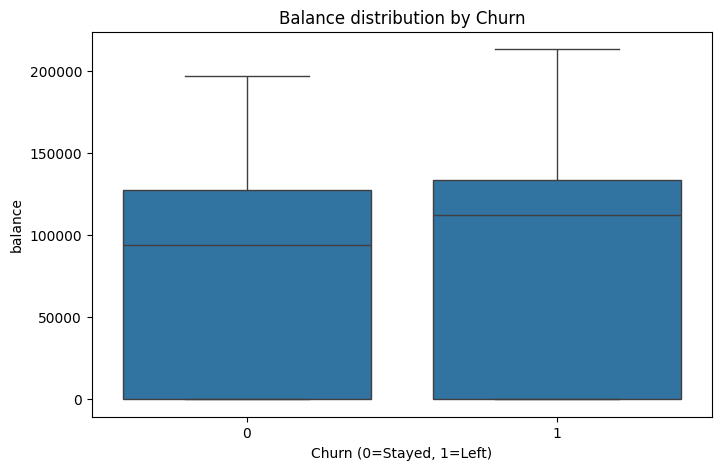

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(x='churn', y='balance', data=df)
plt.title("Balance distribution by Churn")
plt.xlabel("Churn (0=Stayed, 1=Left)")
plt.show()

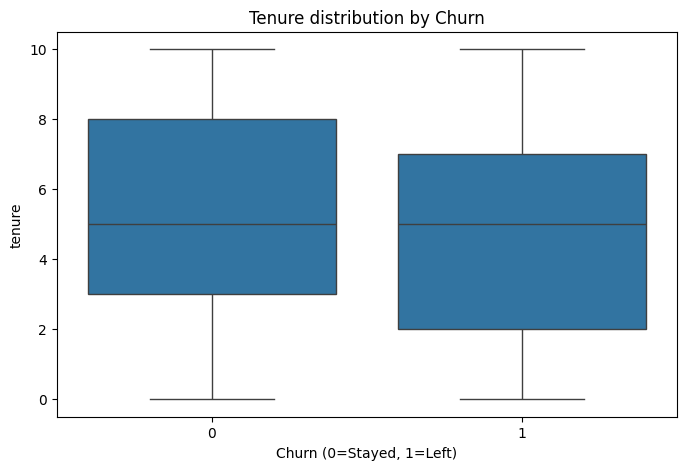

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x='churn', y='tenure', data=df)
plt.title("Tenure distribution by Churn")
plt.xlabel("Churn (0=Stayed, 1=Left)")
plt.show()

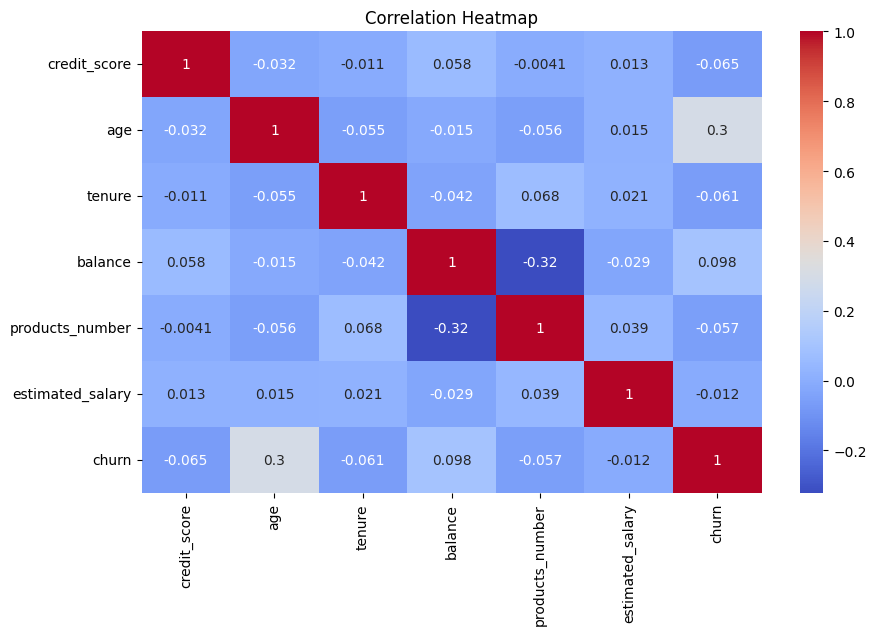

In [12]:
numeric_cols = ['credit_score','age','tenure','balance','products_number','estimated_salary','churn']
plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()